# Light Reconstruction Demo

Minimal notebook to run the lightweight reconstruction pipeline from `src/privacy/light_reconstruction.py`.

In [7]:
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break
os.chdir(repo_root)
print("CWD:", os.getcwd())

CWD: /Users/suetake/git-repos/takano_labo/dca


In [8]:
import matplotlib.pyplot as plt

def show_selected(result, method="pinv"):
    labels = result.selected_labels
    n = len(labels)
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 4.2))
    if n == 1:
        axes = [[axes[0]], [axes[1]]]
    for i, label in enumerate(labels):
        pair = result.selected_images[method][label]
        orig = pair["original"]
        rec = pair["reconstructed"]
        axes[0][i].imshow(orig, cmap="gray")
        axes[0][i].set_title(f"orig label={label}")
        axes[0][i].axis("off")
        axes[1][i].imshow(rec, cmap="gray")
        axes[1][i].set_title(f"recon ({method})")
        axes[1][i].axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
# from config.config import Config
# from src.privacy import run_light_anchor_reconstruction

# cfg = Config(
#     name="light_recon_demo",
#     dataset="mnist",
#     y_name="target",
#     num_institution_user=1000,
#     dim_intermediate=10,
#     F_type="svd",
#     preprocess=False,
#     seed=4,
# )

# res = run_light_anchor_reconstruction(
#     cfg,
#     anchor_labels=(0, 1, 2),
#     display_labels=(0, 1, 2),
#     public_per_label=10,
#     num_anchor_data=300,
#     methods=("pinv", "mlp", "pinv_not_orth"),
#     image_seed_by_label={0: 101, 1: 202, 2: 303},
#     evaluate_classifier_accuracy=False,
#     reconstruct_anchor_images=False,
# )

# print("methods:", res.methods)
# print("selected_labels:", res.selected_labels)
# print("metrics:", res.metrics)

# show_selected(res, method="pinv")

In [10]:
# # Optional: accuracy on selected reconstructed images
# res_eval = run_light_anchor_reconstruction(
#     cfg,
#     anchor_labels=(0, 1, 2),
#     display_labels=(0, 1, 2),
#     public_per_label=10,
#     num_anchor_data=300,
#     methods=("pinv", "mlp", "pinv_not_orth"),
#     image_seed_by_label={0: 101, 1: 202, 2: 303},
#     evaluate_classifier_accuracy=True,
#     rf_train_size=5000,
# )
# res_eval.metrics

In [11]:
# # Seed sweep: F_type x dim_intermediate for non-leak labels 3..9
# import numpy as np
# import pandas as pd
# import importlib
# from sklearn.ensemble import RandomForestClassifier

# # 先頭importに追加
# from pathlib import Path
# from datetime import datetime
# import json
# import pickle

# import src.privacy.light_reconstruction as lr
# importlib.reload(lr)
# run_light_anchor_reconstruction = lr.run_light_anchor_reconstruction
# from config.config import Config
# from src.institution_data_pipeline.load_data import load_data

# try:
#     from tqdm.auto import tqdm
# except Exception:
#     tqdm = lambda x, **kwargs: x

# f_types = ["svd", "kernel_pca_self_tuning", "umap"]
# dim_intermediate_values = [4, 16, 64]
# f_types = ["svd"]
# dim_intermediate_values = [4]
# seeds = list(range(1, 2))  # cfg.seed patterns; use range(1, 11) for 10 seeds
# methods = ("pinv", "mlp", "pinv_not_orth")

# anchor_labels = (0, 1, 2)          # leaked/public anchor labels
# eval_labels = (3, 4, 5, 6, 7, 8, 9) # reconstruction/evaluation labels
# eval_samples_per_label = 50         # 7 labels x 50 = 350 reconstructed samples per run

# # Train the evaluator once and reuse it across all reconstruction runs.
# # Keep classifier_labels = None to train a 10-class MNIST evaluator.
# classifier_labels = None
# shared_rf_train_size = 5000
# classifier_cfg = Config(
#     name="light_recon_shared_rf",
#     dataset="mnist",
#     y_name="target",
#     preprocess=False,
#     seed=0,
# )
# classifier_df = load_data(classifier_cfg)
# classifier_y = classifier_df[classifier_cfg.y_name].to_numpy()
# classifier_X = classifier_df.drop(columns=[classifier_cfg.y_name]).to_numpy(dtype=np.float32)
# if classifier_labels is not None:
#     classifier_mask = np.isin(classifier_y, np.array(classifier_labels))
#     classifier_X = classifier_X[classifier_mask]
#     classifier_y = classifier_y[classifier_mask]
# classifier_rng = np.random.default_rng(0)
# classifier_idx = classifier_rng.permutation(len(classifier_X))[: min(shared_rf_train_size, len(classifier_X))]
# shared_rf = RandomForestClassifier(random_state=0, n_jobs=-1)
# shared_rf.fit(classifier_X[classifier_idx], classifier_y[classifier_idx])

# run_id = f"seed_sweep_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
# save_dir = Path("/Users/suetake/git-repos/takano_labo/dca/output/cikm_recon") / run_id
# save_dir.mkdir(parents=True, exist_ok=True)

# run_meta = {
#     "dataset": "mnist",
#     "f_types": f_types,
#     "dim_intermediate_values": dim_intermediate_values,
#     "seeds": seeds,
#     "methods": methods,
#     "anchor_labels": anchor_labels,
#     "eval_labels": eval_labels,
#     "eval_samples_per_label": eval_samples_per_label,
#     "classifier_labels": classifier_labels,
#     "shared_rf_train_size": shared_rf_train_size,
# }

# summary_rows = []
# error_rows = []
# loop_results = {}

# grid = [
#     (seed, f_type, dim_intermediate)
#     for seed in seeds
#     for f_type in f_types
#     for dim_intermediate in dim_intermediate_values
# ]

# for seed, f_type, dim_intermediate in tqdm(grid, desc="reconstruction seed sweep"):
#     cfg_loop = Config(
#         name=f"light_recon_seed{seed}_{f_type}_d{dim_intermediate}",
#         dataset="mnist",
#         y_name="target",
#         num_institution_user=1000,
#         dim_intermediate=dim_intermediate,
#         F_type=f_type,
#         gamma_ratio=1.0,   # kernel_pca_self_tuning safety
#         preprocess=False,
#         seed=seed,
#     )

#     seed_map = {lab: 1000 * seed + int(lab) for lab in eval_labels}

#     try:
#         res_loop = run_light_anchor_reconstruction(
#             cfg_loop,
#             anchor_labels=anchor_labels,
#             display_labels=eval_labels,
#             samples_per_label=eval_samples_per_label,
#             public_per_label=100,
#             num_anchor_data=300,
#             smote_ratio=1.0,
#             smote_cross_label_ratio=0.0,
#             methods=methods,
#             image_seed_by_label=seed_map,
#             evaluate_classifier_accuracy=True,
#             evaluation_classifier=shared_rf,
#             rf_train_size=shared_rf_train_size,
#             reconstruct_anchor_images=False,
#         )
#     except Exception as exc:
#         error_rows.append(
#             {
#                 "seed": seed,
#                 "F_type": f_type,
#                 "dim_intermediate": dim_intermediate,
#                 "error": repr(exc),
#             }
#         )
#         continue

#     loop_results[(seed, f_type, dim_intermediate)] = res_loop

#     for method in methods:
#         summary_rows.append(
#             {
#                 "seed": seed,
#                 "F_type": f_type,
#                 "dim_intermediate": dim_intermediate,
#                 "eval_labels": "".join(map(str, eval_labels)),
#                 "samples_per_label": eval_samples_per_label,
#                 "n_eval": len(eval_labels) * eval_samples_per_label,
#                 "method": method,
#                 "classifier_labels": ("all" if classifier_labels is None else "".join(map(str, classifier_labels))),
#                 "classifier_accuracy": res_loop.metrics.get(method, {}).get("classifier_accuracy", float("nan")),
#             }
#         )

# summary_df = pd.DataFrame(summary_rows)
# error_df = pd.DataFrame(error_rows)

# accuracy_summary_df = (
#     summary_df
#     .groupby(["F_type", "dim_intermediate", "method"], as_index=False)
#     .agg(
#         accuracy_mean=("classifier_accuracy", "mean"),
#         accuracy_stdev=("classifier_accuracy", "std"),
#         n_seeds=("seed", "nunique"),
#         n_runs=("classifier_accuracy", "count"),
#     )
#     .sort_values(["F_type", "dim_intermediate", "method"])
# )

# accuracy_pivot_df = accuracy_summary_df.pivot_table(
#     index=["F_type", "dim_intermediate"],
#     columns="method",
#     values="accuracy_mean",
# ).reset_index()

# accuracy_pivot_df

# # accuracy_pivot_df の作成後に追加（最後）
# summary_df.to_csv(save_dir / "summary_rows.csv", index=False)
# error_df.to_csv(save_dir / "errors.csv", index=False)
# accuracy_summary_df.to_csv(save_dir / "accuracy_summary.csv", index=False)
# accuracy_pivot_df.to_csv(save_dir / "accuracy_pivot_mean.csv", index=False)

# with open(save_dir / "run_meta.json", "w", encoding="utf-8") as f:
#     json.dump(run_meta, f, ensure_ascii=False, indent=2)

# # loop_results は重いので pickle 保存（不要なら消してOK）
# with open(save_dir / "loop_results.pkl", "wb") as f:
#     pickle.dump(loop_results, f)

# print(f"saved to: {save_dir}")


In [13]:
import numpy as np
import pandas as pd
import importlib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier

import src.privacy.light_reconstruction as lr
importlib.reload(lr)
run_light_anchor_reconstruction = lr.run_light_anchor_reconstruction

from config.config import Config
from src.institution_data_pipeline.load_data import load_data

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ===== 指定するだけ =====
datasets = ["mnist", "fashion_mnist"]
f_types = ["svd", "kernel_pca_self_tuning", "umap"]
dim_intermediate_values = [4, 16, 64]
methods = ["pinv", "mlp", "pinv_not_orth"]
seeds = list(range(1, 11))  # 10 seeds


# # ===== 指定するだけ =====
# datasets = ["mnist", "fashion_mnist"]
# f_types = ["svd", "kernel_pca_self_tuning"]
# dim_intermediate_values = [4,8]
# methods = ["pinv", "mlp"]
# seeds = list(range(1, 2))  # 10 seeds

# ========================

anchor_labels = (0, 1, 2)
eval_labels = (3, 4, 5, 6, 7, 8, 9)
eval_samples_per_label = 50
shared_rf_train_size = 5000

save_dir = Path("/Users/suetake/git-repos/takano_labo/dca/output/cikm_recon")
save_dir.mkdir(parents=True, exist_ok=True)

# datasetごとに評価器を1回だけ学習
rf_by_dataset = {}
for ds in datasets:
    cfg_cls = Config(name=f"light_recon_rf_{ds}", dataset=ds, y_name="target", preprocess=False, seed=0)
    df_cls = load_data(cfg_cls)
    y = df_cls[cfg_cls.y_name].to_numpy()
    X = df_cls.drop(columns=[cfg_cls.y_name]).to_numpy(dtype=np.float32)

    rng = np.random.default_rng(0)
    idx = rng.permutation(len(X))[: min(shared_rf_train_size, len(X))]
    rf = RandomForestClassifier(random_state=0, n_jobs=-1)
    rf.fit(X[idx], y[idx])
    rf_by_dataset[ds] = rf

rows = []
errors = []

grid = [
    (ds, seed, f_type, dim)
    for ds in datasets
    for seed in seeds
    for f_type in f_types
    for dim in dim_intermediate_values
]

for ds, seed, f_type, dim_intermediate in tqdm(grid, desc="recon sweep"):
    cfg = Config(
        name=f"recon_{ds}_s{seed}_{f_type}_d{dim_intermediate}",
        dataset=ds,
        y_name="target",
        num_institution_user=1000,
        dim_intermediate=dim_intermediate,
        F_type=f_type,
        gamma_ratio=1.0,
        preprocess=False,
        seed=seed,
    )
    seed_map = {lab: 1000 * seed + int(lab) for lab in eval_labels}

    try:
        res = run_light_anchor_reconstruction(
            cfg,
            anchor_labels=anchor_labels,
            display_labels=eval_labels,
            samples_per_label=eval_samples_per_label,
            public_per_label=100,
            num_anchor_data=300,
            smote_ratio=1.0,
            smote_cross_label_ratio=0.0,
            methods=methods,
            image_seed_by_label=seed_map,
            evaluate_classifier_accuracy=True,
            evaluation_classifier=rf_by_dataset[ds],
            rf_train_size=shared_rf_train_size,
            reconstruct_anchor_images=False,
        )
        for m in methods:
            rows.append({
                "dataset": ds,
                "F_type": f_type,
                "dim_intermediate": dim_intermediate,
                "seed": seed,
                "method": m,
                "classifier_accuracy": res.metrics.get(m, {}).get("classifier_accuracy", np.nan),
            })
    except Exception as e:
        errors.append({
            "dataset": ds,
            "F_type": f_type,
            "dim_intermediate": dim_intermediate,
            "seed": seed,
            "error": repr(e),
        })

raw_df = pd.DataFrame(rows)
err_df = pd.DataFrame(errors)

# 1つの表（dataset, F_type, dim_intermediate ごとに methods を列化）
summary = (
    raw_df.groupby(["dataset", "F_type", "dim_intermediate", "method"], as_index=False)
    .agg(
        mean_acc=("classifier_accuracy", "mean"),
        std_acc=("classifier_accuracy", "std"),
        n_seeds=("seed", "nunique"),
    )
)
summary["sd_acc"] = summary["std_acc"]

one_table = summary.pivot_table(
    index=["dataset", "F_type", "dim_intermediate"],
    columns="method",
    values=["mean_acc", "sd_acc"],
).reset_index()
one_table.columns = [
    "_".join([str(c) for c in col if c]).strip("_")
    for col in one_table.columns.to_flat_index()
]

# 保存
raw_df.to_csv(save_dir / "recon_raw_by_seed.csv", index=False)
summary.to_csv(save_dir / "recon_summary_long.csv", index=False)
one_table.to_csv(save_dir / "recon_one_table.csv", index=False)
err_df.to_csv(save_dir / "recon_errors.csv", index=False)

print("saved:")
print(save_dir / "recon_one_table.csv")
one_table


cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


recon sweep:   0%|          | 0/180 [00:00<?, ?it/s]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


recon sweep:   1%|          | 1/180 [00:05<15:37,  5.24s/it]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


...

/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
recon sweep:  99%|█████████▉| 179/180 [17:19<00:06,  6.09s/it]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
UMAP seed: 10


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
recon sweep: 100%|██████████| 180/180 [17:25<00:00,  5.81s/it]

saved:
/Users/suetake/git-repos/takano_labo/dca/output/cikm_recon/recon_one_table.csv


,dataset,F_type,dim_intermediate,mean_acc_mlp,mean_acc_pinv,mean_acc_pinv_not_orth,sd_acc_mlp,sd_acc_pinv,sd_acc_pinv_not_orth
0,fashion_mnist,kernel_pca_self_tuning,4,0.072857,0.136286,0.031429,0.028196,0.022938,0.020068
1,fashion_mnist,kernel_pca_self_tuning,16,0.141429,0.322571,0.084286,0.048398,0.037482,0.031335
2,fashion_mnist,kernel_pca_self_tuning,64,0.158571,0.455143,0.197714,0.043315,0.023944,0.036010
3,fashion_mnist,svd,4,0.178286,0.143143,0.214000,0.021684,0.014219,0.021985
4,fashion_mnist,svd,16,0.328857,0.383143,0.558857,0.038058,0.043235,0.042660
5,fashion_mnist,svd,64,0.360571,0.542000,0.674000,0.018507,0.019050,0.049183
6,fashion_mnist,umap,4,0.128286,0.108571,0.052000,0.061963,0.064720,0.034333
7,fashion_mnist,umap,16,0.177714,0.203429,0.040286,0.055432,0.089248,0.028586
8,fashion_mnist,umap,64,0.143429,0.181143,0.080857,0.086555,0.064709,0.041427
9,mnist,kernel_pca_self_tuning,4,0.127429,0.180286,0.142571,0.010707,0.015791,0.000904


In [14]:
import numpy as np
import pandas as pd
import importlib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier

import src.privacy.light_reconstruction as lr
importlib.reload(lr)
run_light_anchor_reconstruction = lr.run_light_anchor_reconstruction

from config.config import Config
from src.institution_data_pipeline.load_data import load_data

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ===== 指定するだけ =====
datasets = ["mnist", "fashion_mnist"]
f_types = ["svd", "kernel_pca_self_tuning", "umap"]
dim_intermediate_values = [4, 16, 64]
methods = ["pinv", "mlp", "pinv_not_orth"]
seeds = list(range(1, 31))  # 30 seeds


# # ===== 指定するだけ =====
# datasets = ["mnist", "fashion_mnist"]
# f_types = ["svd", "kernel_pca_self_tuning"]
# dim_intermediate_values = [4,8]
# methods = ["pinv", "mlp"]
# seeds = list(range(1, 2))  # 10 seeds

# ========================

anchor_labels = (0, 1, 2)
eval_labels = (3, 4, 5, 6, 7, 8, 9)
eval_samples_per_label = 50
shared_rf_train_size = 5000

save_dir = Path("/Users/suetake/git-repos/takano_labo/dca/output/cikm_recon")
save_dir.mkdir(parents=True, exist_ok=True)

# datasetごとに評価器を1回だけ学習
rf_by_dataset = {}
for ds in datasets:
    cfg_cls = Config(name=f"light_recon_rf_{ds}", dataset=ds, y_name="target", preprocess=False, seed=0)
    df_cls = load_data(cfg_cls)
    y = df_cls[cfg_cls.y_name].to_numpy()
    X = df_cls.drop(columns=[cfg_cls.y_name]).to_numpy(dtype=np.float32)

    rng = np.random.default_rng(0)
    idx = rng.permutation(len(X))[: min(shared_rf_train_size, len(X))]
    rf = RandomForestClassifier(random_state=0, n_jobs=-1)
    rf.fit(X[idx], y[idx])
    rf_by_dataset[ds] = rf

rows = []
errors = []

grid = [
    (ds, seed, f_type, dim)
    for ds in datasets
    for seed in seeds
    for f_type in f_types
    for dim in dim_intermediate_values
]

for ds, seed, f_type, dim_intermediate in tqdm(grid, desc="recon sweep"):
    cfg = Config(
        name=f"recon_{ds}_s{seed}_{f_type}_d{dim_intermediate}",
        dataset=ds,
        y_name="target",
        num_institution_user=1000,
        dim_intermediate=dim_intermediate,
        F_type=f_type,
        gamma_ratio=1.0,
        preprocess=False,
        seed=seed,
    )
    seed_map = {lab: 1000 * seed + int(lab) for lab in eval_labels}

    try:
        res = run_light_anchor_reconstruction(
            cfg,
            anchor_labels=anchor_labels,
            display_labels=eval_labels,
            samples_per_label=eval_samples_per_label,
            public_per_label=100,
            num_anchor_data=300,
            smote_ratio=1.0,
            smote_cross_label_ratio=0.0,
            methods=methods,
            image_seed_by_label=seed_map,
            evaluate_classifier_accuracy=True,
            evaluation_classifier=rf_by_dataset[ds],
            rf_train_size=shared_rf_train_size,
            reconstruct_anchor_images=False,
        )
        for m in methods:
            rows.append({
                "dataset": ds,
                "F_type": f_type,
                "dim_intermediate": dim_intermediate,
                "seed": seed,
                "method": m,
                "classifier_accuracy": res.metrics.get(m, {}).get("classifier_accuracy", np.nan),
            })
    except Exception as e:
        errors.append({
            "dataset": ds,
            "F_type": f_type,
            "dim_intermediate": dim_intermediate,
            "seed": seed,
            "error": repr(e),
        })

raw_df = pd.DataFrame(rows)
err_df = pd.DataFrame(errors)

# 1つの表（dataset, F_type, dim_intermediate ごとに methods を列化）
summary = (
    raw_df.groupby(["dataset", "F_type", "dim_intermediate", "method"], as_index=False)
    .agg(
        mean_acc=("classifier_accuracy", "mean"),
        std_acc=("classifier_accuracy", "std"),
        n_seeds=("seed", "nunique"),
    )
)
summary["sd_acc"] = summary["std_acc"]

one_table = summary.pivot_table(
    index=["dataset", "F_type", "dim_intermediate"],
    columns="method",
    values=["mean_acc", "sd_acc"],
).reset_index()
one_table.columns = [
    "_".join([str(c) for c in col if c]).strip("_")
    for col in one_table.columns.to_flat_index()
]

# 保存
raw_df.to_csv(save_dir / "recon_raw_by_seed.csv", index=False)
summary.to_csv(save_dir / "recon_summary_long.csv", index=False)
one_table.to_csv(save_dir / "recon_one_table.csv", index=False)
err_df.to_csv(save_dir / "recon_errors.csv", index=False)

print("saved:")
print(save_dir / "recon_one_table.csv")
one_table


cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


recon sweep:   0%|          | 0/540 [00:00<?, ?it/s]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


recon sweep:   0%|          | 1/540 [00:05<50:04,  5.57s/it]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


...

/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
recon sweep: 100%|█████████▉| 539/540 [56:18<00:05,  5.29s/it]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
UMAP seed: 30


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
recon sweep: 100%|██████████| 540/540 [56:24<00:00,  6.27s/it]

saved:
/Users/suetake/git-repos/takano_labo/dca/output/cikm_recon/recon_one_table.csv


,dataset,F_type,dim_intermediate,mean_acc_mlp,mean_acc_pinv,mean_acc_pinv_not_orth,sd_acc_mlp,sd_acc_pinv,sd_acc_pinv_not_orth
0,fashion_mnist,kernel_pca_self_tuning,4,0.079905,0.142286,0.029905,0.038071,0.018446,0.018694
1,fashion_mnist,kernel_pca_self_tuning,16,0.168857,0.326095,0.089619,0.059177,0.030550,0.035492
2,fashion_mnist,kernel_pca_self_tuning,64,0.153143,0.454286,0.196476,0.065715,0.033555,0.040089
3,fashion_mnist,svd,4,0.164190,0.140190,0.211429,0.025397,0.016608,0.019724
4,fashion_mnist,svd,16,0.330476,0.382667,0.556667,0.040339,0.033260,0.030424
5,fashion_mnist,svd,64,0.366286,0.551619,0.687048,0.031837,0.029767,0.040223
6,fashion_mnist,umap,4,0.150571,0.111524,0.043810,0.076889,0.071511,0.037073
7,fashion_mnist,umap,16,0.190857,0.220095,0.040571,0.079170,0.088721,0.026775
8,fashion_mnist,umap,64,0.177048,0.189238,0.078000,0.090853,0.055952,0.033891
9,mnist,kernel_pca_self_tuning,4,0.127714,0.188000,0.142762,0.010210,0.018899,0.000522


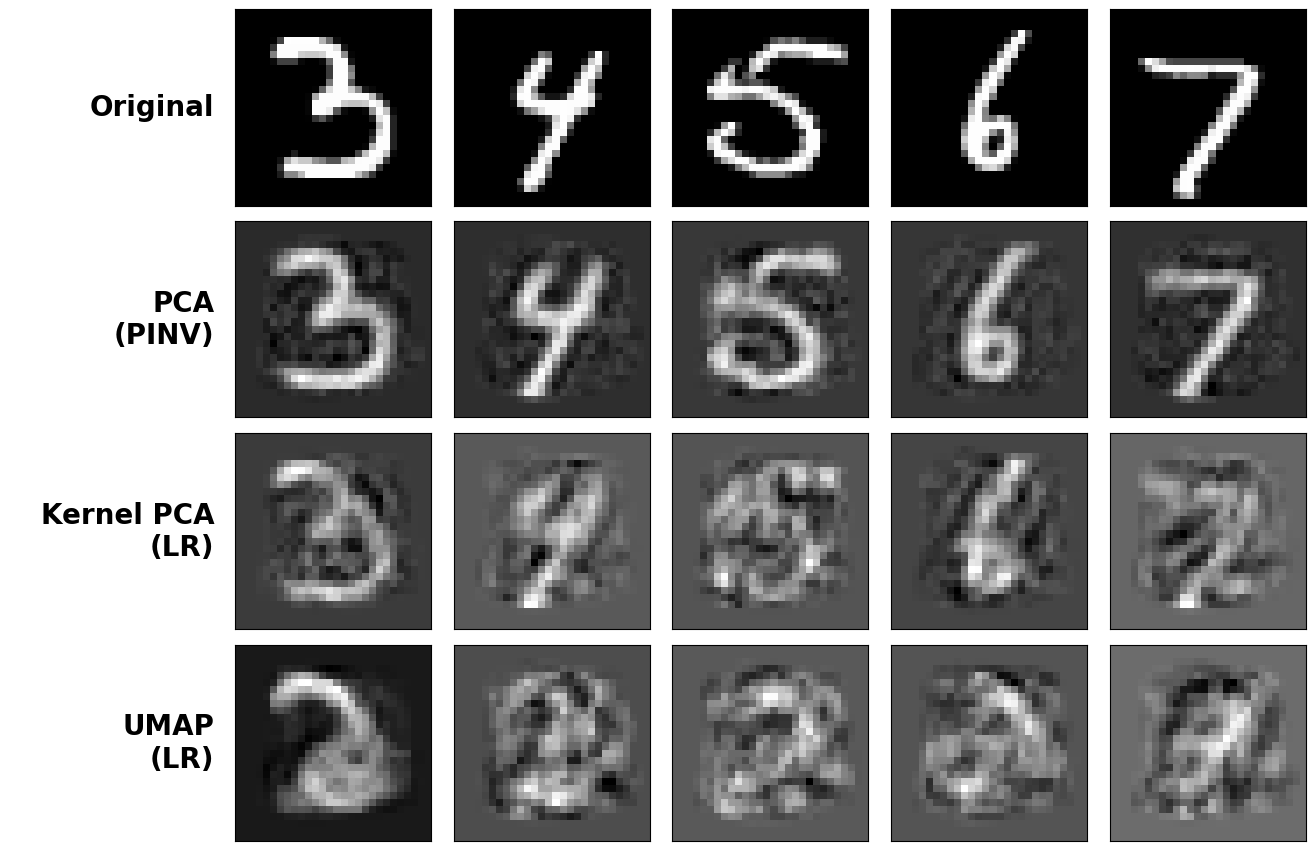

saved: /Users/suetake/git-repos/takano_labo/dca/output/recon/recon_64_4rows_seed101_102_101_104_103.png


In [6]:
import os
import io
import contextlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from config.config import Config
from src.privacy import run_light_anchor_reconstruction

# ========= base settings (貼ってくれた内容ベース) =========
anchor_labels=(0,1,2)
display_labels = (3, 4, 5, 6, 7)
image_seed_by_label = {3: 101, 4: 102, 5: 101, 6: 104, 7: 103}

common_kwargs = dict(
    anchor_labels=anchor_labels,
    display_labels=display_labels,
    public_per_label=100,
    num_anchor_data=300,
    evaluate_classifier_accuracy=False,
    reconstruct_anchor_images=False,
    image_seed_by_label=image_seed_by_label,
)

base_cfg = dict(
    dataset="mnist",
    y_name="target",
    num_institution_user=1000,
    dim_intermediate=64,
    preprocess=False,
    seed=4,
)

rows = [
    ("Original", None, None),
    ("PCA\n(PINV)", "svd", "PINV"),
    ("Kernel PCA\n(LR)", "kernel_pca_self_tuning", "LinRegr"),
    ("UMAP\n(LR)", "umap", "LinRegr"),
]

def run_quiet(*args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return run_light_anchor_reconstruction(*args, **kwargs)

original_data = None
recon_data = {}

for row_label, f_type, attack in rows:
    if f_type is None:
        continue
    cfg = Config(name=f"recon_{f_type}_d64", F_type=f_type, **base_cfg)
    res = run_quiet(cfg, methods=(attack,), **common_kwargs)

    if original_data is None:
        original_data = {lab: res.selected_images[attack][lab]["original"] for lab in display_labels}
    recon_data[row_label] = {lab: res.selected_images[attack][lab]["reconstructed"] for lab in display_labels}

# ========= plot 4-row grid =========
n_rows = 4
n_cols = len(display_labels)

fig = plt.figure(figsize=(2.8 * (n_cols + 1.0), 2.7 * n_rows))
gs = gridspec.GridSpec(
    n_rows, n_cols + 1,
    width_ratios=[1] + [1] * n_cols,
    wspace=0.05, hspace=0.08
)

row_order = [r[0] for r in rows]
for r, row_name in enumerate(row_order):
    ax_l = fig.add_subplot(gs[r, 0])
    ax_l.axis("off")
    ax_l.text(0.98, 0.5, row_name, ha="right", va="center", fontsize=20, fontweight="bold")

    for c, lab in enumerate(display_labels):
        ax = fig.add_subplot(gs[r, c + 1])
        img = original_data[lab] if r == 0 else recon_data[row_name][lab]
        ax.imshow(img, cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])

out_dir = "/Users/suetake/git-repos/takano_labo/dca/output/recon"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "recon_64_4rows_seed101_102_101_104_103.png")

plt.savefig(out_path, dpi=240, bbox_inches="tight")
plt.show()
print("saved:", out_path)
